# Baseline benchmarks: NIH ChestX-ray14 full single-label subset

Notebook trenuje bazowe modele klasyfikacyjne na pełnym single-label folderze:

```text
../data_single_label_full/
├── images/
└── labels.csv
```

Cel tego kroku: uzyskać baseline na danych oryginalnych, zanim porównamy klasyczną augmentację, GAN/StyleGAN-ADA i diffusion.

Modele w tym notebooku:

- `DenseNet121` z wagami ImageNet z `torchvision`
- `Swin-Tiny` z wagami ImageNet z `timm`

Split robimy po `patient_id`, żeby obrazy tego samego pacjenta nie trafiały jednocześnie do train i test.

## How to run training

**Recommended:** run the baseline training from the terminal, not from the notebook. The training takes a long time and terminal execution is easier to monitor and resume around.

From the repository root run:

```bash
python scripts/train_baselines.py
```

The rest of this notebook expects artifacts produced by that script in `outputs/advanced_baselines_full/`, especially `all_history.csv`, `test_summary.csv`, `best.pt`, and `test_predictions.csv`.

The next code cell contains the notebook equivalent, but it is intentionally commented out. Use it only if you explicitly want to launch training from Jupyter.


In [ ]:
# OPTIONAL NOTEBOOK TRAINING ENTRYPOINT
# Recommended workflow: run this from the terminal instead:
#     python scripts/train_baselines.py

# MODELS_TO_RUN = [
#     "densenet121",
#     "swin_tiny",
# ]
#
# histories = []
# trained_models = {}
#
# for model_name in MODELS_TO_RUN:
#     if model_name == "swin_tiny" and timm is None:
#         print("Skipping swin_tiny because timm is not installed.")
#         continue
#
#     print("=" * 80)
#     print("Training", model_name)
#     model, history_df = train_model(model_name)
#     trained_models[model_name] = model
#     histories.append(history_df)
#
# all_history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
# all_history.to_csv(cfg.output_dir / "all_history.csv", index=False)
# all_history


## 0. Install dependencies

## 1. Importy i konfiguracja

In [1]:
from __future__ import annotations

import json
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

try:
    import timm
except ImportError:
    timm = None
    print("timm is not installed. Install it to run Swin-Tiny: %pip install timm")

/home/mikolaj/work/medical-image-data-augmentation-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass
class Config:
    data_dir: Path = Path("../data_single_label_full")
    output_dir: Path = Path("../outputs/advanced_baselines_full")
    image_size: int = 512
    batch_size: int = 64
    num_workers: int = 4
    epochs: int = 50
    seed: int = 42

    # This notebook now analyzes runs created by scripts/train_baselines.py by default.
    run_training: bool = False
    run_full_split_inference: bool = False  # set True to compute train/val/test per-class metrics from checkpoints

    # Transfer-learning setup used by the script. Baseline uses no image augmentation.
    fine_tune_mode: str = "last_blocks"  # one of: head_only, last_blocks, full
    use_class_weights: bool = True
    label_smoothing: float = 0.0

    # Differential LR: small for pre-trained backbone, larger for head.
    backbone_lr: float = 5e-5
    head_lr: float = 3e-4
    weight_decay: float = 1e-4

    # Training stabilizers used by the script.
    use_amp: bool = True
    grad_clip_norm: float | None = 1.0
    monitor_metric: str = "val_macro_f1"
    min_delta: float = 1e-4
    early_stopping_patience: int = 6

    # Scheduler options used by the script.
    scheduler: str = "reduce_on_plateau"
    scheduler_patience: int = 2
    scheduler_factor: float = 0.5
    min_lr: float = 1e-6

    # Debug switches; leave None for real training/inference.
    max_train_batches: int | None = None
    max_eval_batches: int | None = None


cfg = Config()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

labels_csv = cfg.data_dir / "labels.csv"
images_dir = cfg.data_dir / "images"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("labels_csv:", labels_csv.resolve())
print("images_dir:", images_dir.resolve())
print("output_dir:", cfg.output_dir.resolve())


device: cuda
labels_csv: /home/mikolaj/work/medical-image-data-augmentation-benchmark/data_single_label_full/labels.csv
images_dir: /home/mikolaj/work/medical-image-data-augmentation-benchmark/data_single_label_full/images
output_dir: /home/mikolaj/work/medical-image-data-augmentation-benchmark/outputs/advanced_baselines_full


In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(cfg.seed)

## 2. Wczytanie etykiet i sanity check

In [4]:
df = pd.read_csv(labels_csv)
df["image_path"] = df["image"].map(lambda name: images_dir / name)
df["exists"] = df["image_path"].map(lambda path: path.exists())

print("rows:", len(df))
print("images on disk:", len(list(images_dir.glob("*.png"))))
print("missing images:", int((~df["exists"]).sum()))

assert set(["image", "label", "patient_id"]).issubset(df.columns)
assert df["exists"].all(), "Some images listed in labels.csv are missing."

class_counts = df["label"].value_counts().rename_axis("label").reset_index(name="count")
class_counts["share"] = class_counts["count"] / len(df)
class_counts

rows: 91324
images on disk: 91324
missing images: 0


,label,count,share
0,No Finding,60361,0.660954
1,Infiltration,9547,0.104540
2,Atelectasis,4215,0.046154
3,Effusion,3955,0.043307
4,Nodule,2705,0.029620
5,Pneumothorax,2194,0.024024
6,Mass,2139,0.023422
7,Consolidation,1310,0.014345
8,Pleural_Thickening,1126,0.012330
9,Cardiomegaly,1093,0.011968


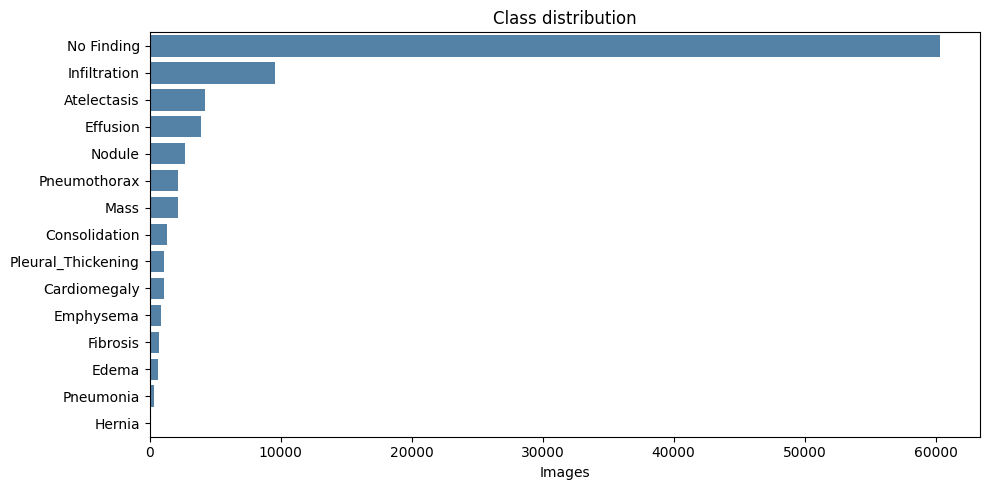

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=class_counts, x="count", y="label", color="steelblue")
plt.title("Class distribution")
plt.xlabel("Images")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 3. Kodowanie klas i split po pacjentach

Używamy splitu po `patient_id`, żeby uniknąć leakage. Najpierw próbujemy `StratifiedGroupKFold`, który zachowuje klasy lepiej niż czysty split grupowy. Jeśli wersja `scikit-learn` albo dane sprawią problem, fallbackiem jest `GroupShuffleSplit`.

In [6]:
classes = sorted(df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(classes)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
df["target"] = df["label"].map(label_to_idx)

with (cfg.output_dir / "label_mapping.json").open("w") as f:
    json.dump(label_to_idx, f, indent=2)

num_classes = len(classes)
num_classes, label_to_idx

(15,
 {'Atelectasis': 0,
  'Cardiomegaly': 1,
  'Consolidation': 2,
  'Edema': 3,
  'Effusion': 4,
  'Emphysema': 5,
  'Fibrosis': 6,
  'Hernia': 7,
  'Infiltration': 8,
  'Mass': 9,
  'No Finding': 10,
  'Nodule': 11,
  'Pleural_Thickening': 12,
  'Pneumonia': 13,
  'Pneumothorax': 14})

In [7]:
def make_patient_split(data: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # 5-fold gives roughly 80/20. Then a second split creates validation from train.
    try:
        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        train_val_idx, test_idx = next(
            sgkf.split(data, y=data["target"], groups=data["patient_id"])
        )
        train_val = data.iloc[train_val_idx].copy()
        test = data.iloc[test_idx].copy()

        sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed + 1)
        train_idx, val_idx = next(
            sgkf_val.split(
                train_val,
                y=train_val["target"],
                groups=train_val["patient_id"],
            )
        )
        train = train_val.iloc[train_idx].copy()
        val = train_val.iloc[val_idx].copy()
        return train, val, test
    except Exception as exc:
        print("StratifiedGroupKFold failed, using GroupShuffleSplit fallback:", repr(exc))
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
        train_val_idx, test_idx = next(splitter.split(data, groups=data["patient_id"]))
        train_val = data.iloc[train_val_idx].copy()
        test = data.iloc[test_idx].copy()

        splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed + 1)
        train_idx, val_idx = next(splitter_val.split(train_val, groups=train_val["patient_id"]))
        train = train_val.iloc[train_idx].copy()
        val = train_val.iloc[val_idx].copy()
        return train, val, test


train_df, val_df, test_df = make_patient_split(df, cfg.seed)

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, len(split_df), "patients", split_df["patient_id"].nunique())

assert set(train_df["patient_id"]).isdisjoint(set(val_df["patient_id"]))
assert set(train_df["patient_id"]).isdisjoint(set(test_df["patient_id"]))
assert set(val_df["patient_id"]).isdisjoint(set(test_df["patient_id"]))

train 58447 patients 18919
val 14611 patients 4725
test 18266 patients 5920


In [8]:
def split_distribution(split_df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = split_df["label"].value_counts().reindex(classes, fill_value=0).rename_axis("label").reset_index(name=name)
    out[f"{name}_share"] = out[name] / len(split_df)
    return out


dist = split_distribution(train_df, "train")
dist = dist.merge(split_distribution(val_df, "val"), on="label")
dist = dist.merge(split_distribution(test_df, "test"), on="label")
dist

,label,train,train_share,val,val_share,test,test_share
0,Atelectasis,2698,0.046161,674,0.046130,843,0.046151
1,Cardiomegaly,699,0.011960,175,0.011977,219,0.011989
2,Consolidation,839,0.014355,209,0.014304,262,0.014344
3,Edema,402,0.006878,101,0.006913,125,0.006843
4,Effusion,2532,0.043321,632,0.043255,791,0.043305
5,Emphysema,571,0.009770,142,0.009719,179,0.009800
6,Fibrosis,465,0.007956,116,0.007939,146,0.007993
7,Hernia,70,0.001198,18,0.001232,22,0.001204
8,Infiltration,6109,0.104522,1528,0.104579,1910,0.104566
9,Mass,1369,0.023423,342,0.023407,428,0.023432


In [9]:
train_df.to_csv(cfg.output_dir / "train_split.csv", index=False)
val_df.to_csv(cfg.output_dir / "val_split.csv", index=False)
test_df.to_csv(cfg.output_dir / "test_split.csv", index=False)
dist.to_csv(cfg.output_dir / "split_class_distribution.csv", index=False)

## 4. Dataset, transformacje i DataLoadery

In [10]:
baseline_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_transform = baseline_transform
eval_transform = baseline_transform


class ChestXrayDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        target = int(row["target"])
        return image, target


train_ds = ChestXrayDataset(train_df, train_transform)
val_ds = ChestXrayDataset(val_df, eval_transform)
test_ds = ChestXrayDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

len(train_ds), len(val_ds), len(test_ds)

(58447, 14611, 18266)

## 5. Podgląd batcha

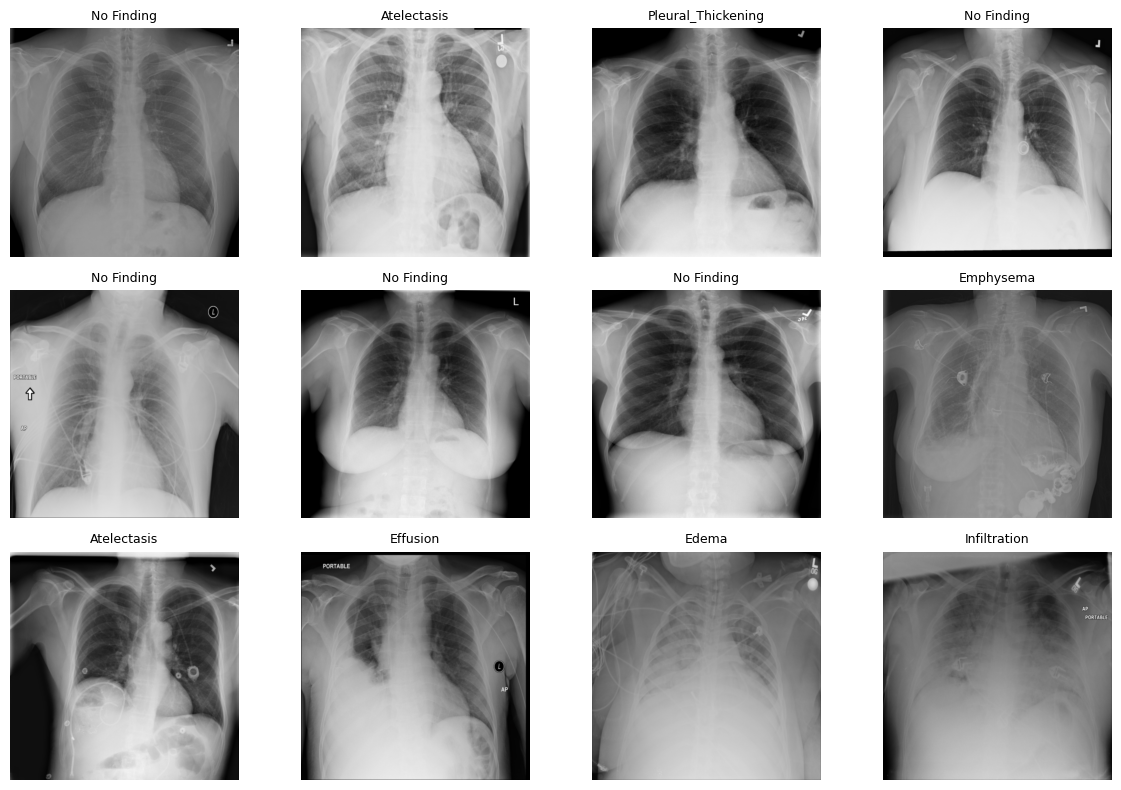

In [11]:
def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


images, targets = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(idx_to_label[int(targets[i])], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Modele pretrained

In [12]:
def set_trainable(module: nn.Module, trainable: bool) -> None:
    for param in module.parameters():
        param.requires_grad = trainable


def build_densenet121(num_classes: int, fine_tune_mode: str) -> nn.Module:
    weights = models.DenseNet121_Weights.IMAGENET1K_V1
    model = models.densenet121(weights=weights)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    if fine_tune_mode == "head_only":
        set_trainable(model, False)
        set_trainable(model.classifier, True)
    elif fine_tune_mode == "last_blocks":
        set_trainable(model, False)
        for name, param in model.named_parameters():
            if name.startswith(("features.denseblock4", "features.norm5", "classifier")):
                param.requires_grad = True
    elif fine_tune_mode == "full":
        set_trainable(model, True)
    else:
        raise ValueError(f"Unknown fine_tune_mode: {fine_tune_mode}")
    return model


def build_swin_tiny(num_classes: int, fine_tune_mode: str, image_size: int = 512) -> nn.Module:
    if timm is None:
        raise ImportError("Install timm first: %pip install timm")
    model = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes,
        img_size=image_size,
    )

    if fine_tune_mode == "head_only":
        set_trainable(model, False)
        for name, param in model.named_parameters():
            if name.startswith("head"):
                param.requires_grad = True
    elif fine_tune_mode == "last_blocks":
        set_trainable(model, False)
        for name, param in model.named_parameters():
            if (
                name.startswith("head")
                or name.startswith("norm")
                or name.startswith("layers.3")
                or name.startswith("stages.3")
            ):
                param.requires_grad = True
    elif fine_tune_mode == "full":
        set_trainable(model, True)
    else:
        raise ValueError(f"Unknown fine_tune_mode: {fine_tune_mode}")
    return model


def build_model(
    model_name: str,
    num_classes: int,
    fine_tune_mode: str,
    image_size: int = 512,
) -> nn.Module:
    if model_name == "densenet121":
        return build_densenet121(num_classes, fine_tune_mode)
    if model_name == "swin_tiny":
        return build_swin_tiny(num_classes, fine_tune_mode, image_size=image_size)
    raise ValueError(f"Unknown model: {model_name}")


def count_trainable_params(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def trainable_parameter_prefixes(model: nn.Module, max_items: int = 20) -> list[str]:
    names = [name for name, param in model.named_parameters() if param.requires_grad]
    prefixes = []
    for name in names:
        parts = name.split(".")
        prefix = ".".join(parts[:2]) if len(parts) > 1 else parts[0]
        if prefix not in prefixes:
            prefixes.append(prefix)
    return prefixes[:max_items]


## 7. Loss, trening i ewaluacja

Zaawansowany baseline nadal nie używa augmentacji obrazów. Ulepszenia dotyczą wyłącznie optymalizacji: ważony `CrossEntropyLoss`, differential learning rates, AMP, gradient clipping, scheduler i early stopping po `val_macro_f1`.


In [13]:
def make_class_weights(train_frame: pd.DataFrame) -> torch.Tensor:
    counts = train_frame["target"].value_counts().reindex(range(num_classes), fill_value=0).sort_index()
    weights = len(train_frame) / (num_classes * counts.clip(lower=1))
    return torch.tensor(weights.values, dtype=torch.float32)


class_weights = make_class_weights(train_df).to(device) if cfg.use_class_weights else None
class_weights


tensor([ 1.4442,  5.5743,  4.6442,  9.6927,  1.5389,  6.8239,  8.3795, 55.6638,
         0.6378,  2.8462,  0.1009,  2.2510,  5.4043, 18.9149,  2.7753],
       device='cuda:0')

In [14]:
def make_optimizer(model: nn.Module) -> torch.optim.Optimizer:
    head_params = []
    backbone_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("classifier") or name.startswith("head"):
            head_params.append(param)
        else:
            backbone_params.append(param)

    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": cfg.backbone_lr, "name": "backbone"})
    if head_params:
        param_groups.append({"params": head_params, "lr": cfg.head_lr, "name": "head"})

    if not param_groups:
        raise ValueError("No trainable parameters found.")

    print("optimizer groups:", [(group["name"], group["lr"], len(group["params"])) for group in param_groups])
    return torch.optim.AdamW(param_groups, weight_decay=cfg.weight_decay)


def make_scheduler(optimizer: torch.optim.Optimizer, steps_per_epoch: int):
    if cfg.scheduler == "none":
        return None
    if cfg.scheduler == "reduce_on_plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=cfg.scheduler_factor,
            patience=cfg.scheduler_patience,
            min_lr=cfg.min_lr,
        )
    if cfg.scheduler == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, cfg.epochs),
            eta_min=cfg.min_lr,
        )
    raise ValueError(f"Unknown scheduler: {cfg.scheduler}")


def current_lrs(optimizer: torch.optim.Optimizer) -> dict[str, float]:
    return {
        group.get("name", f"group_{idx}"): group["lr"]
        for idx, group in enumerate(optimizer.param_groups)
    }


def make_grad_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except TypeError:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
    scaler=None,
    max_batches: int | None = None,
) -> dict:
    training = optimizer is not None
    model.train(training)

    amp_enabled = bool(cfg.use_amp and device.type == "cuda")
    total_loss = 0.0
    y_true = []
    y_pred = []

    progress = tqdm(loader, leave=False)
    for batch_idx, (images, targets) in enumerate(progress):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with torch.set_grad_enabled(training):
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                logits = model(images)
                loss = criterion(logits, targets)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                if cfg.grad_clip_norm is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        [param for param in model.parameters() if param.requires_grad],
                        cfg.grad_clip_norm,
                    )
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(targets.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        progress.set_postfix(loss=loss.item())

    avg_loss = total_loss / max(1, len(y_true))
    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }


@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader) -> tuple[list[int], list[int]]:
    model.eval()
    amp_enabled = bool(cfg.use_amp and device.type == "cuda")
    y_true = []
    y_pred = []
    for images, targets in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(images)
        preds = logits.argmax(dim=1).detach().cpu().numpy().tolist()
        y_true.extend(targets.numpy().tolist())
        y_pred.extend(preds)
    return y_true, y_pred


In [15]:
def train_model(model_name: str) -> tuple[nn.Module, pd.DataFrame]:
    seed_everything(cfg.seed)
    run_name = f"{model_name}_{cfg.fine_tune_mode}"
    model_dir = cfg.output_dir / run_name
    model_dir.mkdir(parents=True, exist_ok=True)

    model = build_model(model_name, num_classes, cfg.fine_tune_mode).to(device)
    print(model_name, "fine_tune_mode:", cfg.fine_tune_mode)
    print(model_name, "trainable params:", f"{count_trainable_params(model):,}")
    print(model_name, "trainable prefixes:", trainable_parameter_prefixes(model))

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=cfg.label_smoothing,
    )
    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer, steps_per_epoch=len(train_loader))
    scaler = make_grad_scaler(enabled=bool(cfg.use_amp and device.type == "cuda"))

    best_metric = -float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, cfg.epochs + 1):
        start = time.time()
        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            scaler=scaler,
            max_batches=cfg.max_train_batches,
        )
        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            scaler=None,
            max_batches=cfg.max_eval_batches,
        )
        elapsed = time.time() - start

        row = {
            "model": model_name,
            "run_name": run_name,
            "fine_tune_mode": cfg.fine_tune_mode,
            "epoch": epoch,
            "seconds": elapsed,
            "lr_backbone": current_lrs(optimizer).get("backbone"),
            "lr_head": current_lrs(optimizer).get("head"),
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_balanced_accuracy": train_metrics["balanced_accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "train_macro_recall": train_metrics["macro_recall"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_macro_recall": val_metrics["macro_recall"],
            "val_weighted_f1": val_metrics["weighted_f1"],
        }
        history.append(row)
        print(row)

        monitor_value = row[cfg.monitor_metric]
        improved = monitor_value > best_metric + cfg.min_delta

        if improved:
            best_metric = monitor_value
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_name": model_name,
                    "run_name": run_name,
                    "model_state_dict": model.state_dict(),
                    "label_to_idx": label_to_idx,
                    "config": {k: str(v) if isinstance(v, Path) else v for k, v in asdict(cfg).items()},
                    "epoch": epoch,
                    "monitor_metric": cfg.monitor_metric,
                    "best_metric": best_metric,
                    "val_metrics": {k: v for k, v in row.items() if k.startswith("val_")},
                },
                model_dir / "best.pt",
            )
        else:
            epochs_without_improvement += 1

        if scheduler is not None:
            if cfg.scheduler == "reduce_on_plateau":
                scheduler.step(monitor_value)
            else:
                scheduler.step()

        history_df = pd.DataFrame(history)
        history_df.to_csv(model_dir / "history.csv", index=False)

        if epochs_without_improvement >= cfg.early_stopping_patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best {cfg.monitor_metric}={best_metric:.4f} at epoch {best_epoch}."
            )
            break

    torch.save(
        {
            "model_name": model_name,
            "run_name": run_name,
            "model_state_dict": model.state_dict(),
            "label_to_idx": label_to_idx,
            "config": {k: str(v) if isinstance(v, Path) else v for k, v in asdict(cfg).items()},
            "epoch": history[-1]["epoch"],
        },
        model_dir / "last.pt",
    )

    best_summary = {
        "model": model_name,
        "run_name": run_name,
        "best_epoch": best_epoch,
        "monitor_metric": cfg.monitor_metric,
        "best_metric": best_metric,
    }
    (model_dir / "best_summary.json").write_text(json.dumps(best_summary, indent=2))
    return model, pd.DataFrame(history)


## 8. Optional training launch

Najlepiej uruchamiać trening z terminala, bo jest długi, łatwiej obserwować logi i bezpieczniej zostawić proces poza notebookiem:

```bash
python scripts/train_baselines.py
```

Poniższa komórka pokazuje notebookowy odpowiednik odpalenia treningu. Jest celowo zakomentowana. Odkomentuj ją tylko wtedy, gdy naprawdę chcesz trenować z poziomu notebooka zamiast korzystać ze skryptu.


In [ ]:
# Optional: run training inside the notebook.
# Recommended workflow: run `python scripts/train_baselines.py` from the terminal instead.

# histories = []
# trained_models = {}
#
# for model_name in MODELS_TO_RUN:
#     if model_name == "swin_tiny" and timm is None:
#         print("Skipping swin_tiny because timm is not installed.")
#         continue
#
#     print("=" * 80)
#     print("Training", model_name)
#     model, history_df = train_model(model_name)
#     trained_models[model_name] = model
#     histories.append(history_df)
#
# all_history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
# all_history.to_csv(cfg.output_dir / "all_history.csv", index=False)
# all_history


## 9. Load trained runs from script

Ta sekcja nie trenuje modeli. Ładuje artefakty zapisane przez `python scripts/train_baselines.py`: `all_history.csv`, `test_summary.csv`, checkpointi i predykcje testowe dla `densenet121_last_blocks` oraz `swin_tiny_last_blocks`.


In [16]:
MODELS_TO_RUN = [
    "densenet121",
    "swin_tiny",
]
RUN_NAMES = [f"{model_name}_{cfg.fine_tune_mode}" for model_name in MODELS_TO_RUN]

history_path = cfg.output_dir / "all_history.csv"
test_summary_path = cfg.output_dir / "test_summary.csv"

if not history_path.exists():
    raise FileNotFoundError(
        f"Missing {history_path}. Run `python scripts/train_baselines.py` first."
    )

all_history = pd.read_csv(history_path)
all_history = all_history[all_history["run_name"].isin(RUN_NAMES)].copy()

if test_summary_path.exists():
    test_summary_df = pd.read_csv(test_summary_path)
    test_summary_df = test_summary_df[test_summary_df["run_name"].isin(RUN_NAMES)].copy()
else:
    test_summary_df = pd.DataFrame()

best_val_df = (
    all_history.sort_values(["run_name", "val_macro_f1", "epoch"])
    .groupby("run_name", as_index=False)
    .tail(1)
    .sort_values("val_macro_f1", ascending=False)
)

print("Loaded history:", history_path)
print("Runs:", all_history["run_name"].unique().tolist())
best_val_df[["model", "run_name", "epoch", "val_macro_f1", "val_balanced_accuracy", "val_loss"]]


Loaded history: ../outputs/advanced_baselines_full/all_history.csv
Runs: ['densenet121_last_blocks', 'swin_tiny_last_blocks']


,model,run_name,epoch,val_macro_f1,val_balanced_accuracy,val_loss
30,swin_tiny,swin_tiny_last_blocks,15,0.162840,0.203099,4.746838
9,densenet121,densenet121_last_blocks,10,0.146312,0.193593,3.281811


## 10. Training and validation curves from `all_history.csv`


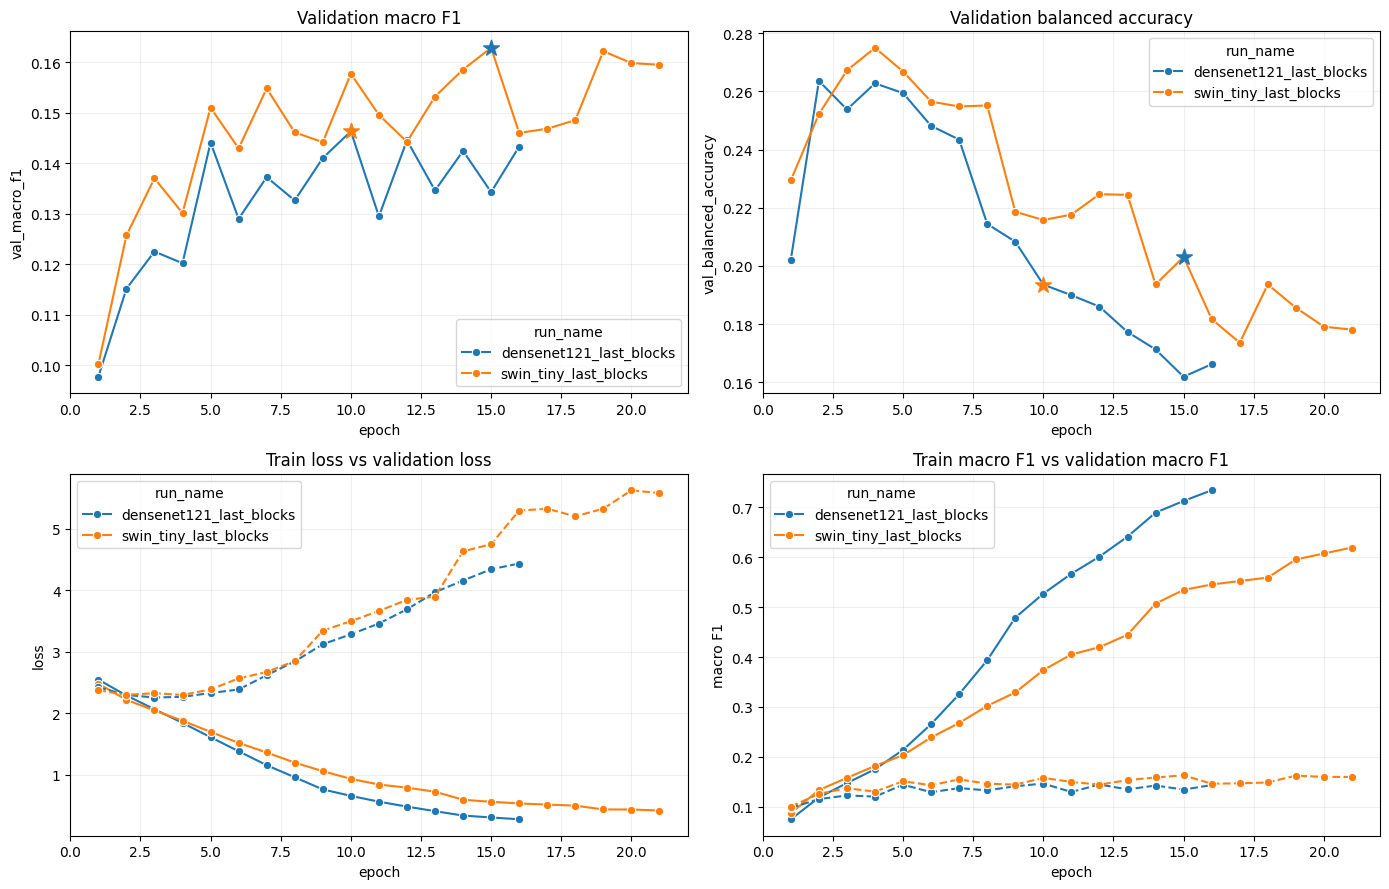

,model,run_name,epoch,val_macro_f1,val_balanced_accuracy,train_loss,val_loss
30,swin_tiny,swin_tiny_last_blocks,15,0.162840,0.203099,0.558728,4.746838
9,densenet121,densenet121_last_blocks,10,0.146312,0.193593,0.655118,3.281811


In [17]:
if not all_history.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    sns.lineplot(
        data=all_history,
        x="epoch",
        y="val_macro_f1",
        hue="run_name",
        marker="o",
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Validation macro F1")

    sns.lineplot(
        data=all_history,
        x="epoch",
        y="val_balanced_accuracy",
        hue="run_name",
        marker="o",
        ax=axes[0, 1],
    )
    axes[0, 1].set_title("Validation balanced accuracy")

    sns.lineplot(
        data=all_history,
        x="epoch",
        y="train_loss",
        hue="run_name",
        marker="o",
        ax=axes[1, 0],
    )
    sns.lineplot(
        data=all_history,
        x="epoch",
        y="val_loss",
        hue="run_name",
        marker="o",
        linestyle="--",
        ax=axes[1, 0],
        legend=False,
    )
    axes[1, 0].set_title("Train loss vs validation loss")
    axes[1, 0].set_ylabel("loss")

    sns.lineplot(
        data=all_history,
        x="epoch",
        y="train_macro_f1",
        hue="run_name",
        marker="o",
        ax=axes[1, 1],
    )
    sns.lineplot(
        data=all_history,
        x="epoch",
        y="val_macro_f1",
        hue="run_name",
        marker="o",
        linestyle="--",
        ax=axes[1, 1],
        legend=False,
    )
    axes[1, 1].set_title("Train macro F1 vs validation macro F1")
    axes[1, 1].set_ylabel("macro F1")

    for _, row in best_val_df.iterrows():
        axes[0, 0].scatter(row["epoch"], row["val_macro_f1"], s=140, marker="*", zorder=5)
        axes[0, 1].scatter(row["epoch"], row["val_balanced_accuracy"], s=140, marker="*", zorder=5)

    for ax in axes.flat:
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

best_val_df[[
    "model",
    "run_name",
    "epoch",
    "val_macro_f1",
    "val_balanced_accuracy",
    "train_loss",
    "val_loss",
]]


## 11. Test-set summary from `test_summary.csv`


,model,run_name,best_epoch,best_val_metric,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_macro_recall
0,densenet121,densenet121_last_blocks,10,0.146312,0.271050,0.198678,0.142779,0.322046,0.198678
1,swin_tiny,swin_tiny_last_blocks,15,0.162840,0.392314,0.210301,0.169091,0.442331,0.210301


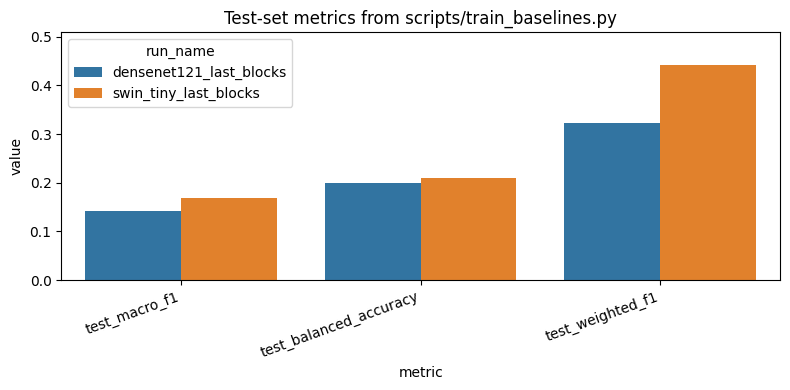

In [18]:
if test_summary_df.empty:
    print("No test_summary.csv found. Run scripts/train_baselines.py or run checkpoint evaluation below.")
else:
    display(test_summary_df[[
        "model",
        "run_name",
        "best_epoch",
        "best_val_metric",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
        "test_macro_recall",
    ]])

    plt.figure(figsize=(8, 4))
    summary_long = test_summary_df.melt(
        id_vars=["run_name"],
        value_vars=["test_macro_f1", "test_balanced_accuracy", "test_weighted_f1"],
        var_name="metric",
        value_name="value",
    )
    sns.barplot(data=summary_long, x="metric", y="value", hue="run_name")
    plt.title("Test-set metrics from scripts/train_baselines.py")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, max(0.5, summary_long["value"].max() * 1.15))
    plt.tight_layout()
    plt.show()


## 12. Per-class metrics on train/val/test

Ta sekcja liczy metryki per klasa dla najlepszego checkpointu każdego modelu na wszystkich splitach. To jest kosztowniejsze niż sam test, bo przechodzi także przez cały train set, ale daje pełny obraz overfittingu i klas, na których model faktycznie działa.


In [19]:
def checkpoint_dir_name(model_name: str) -> str:
    return f"{model_name}_{cfg.fine_tune_mode}"


def load_best_model(model_name: str) -> nn.Module:
    ckpt_path = cfg.output_dir / checkpoint_dir_name(model_name) / "best.pt"
    checkpoint = torch.load(ckpt_path, map_location=device)
    checkpoint_cfg = checkpoint.get("config", {})
    fine_tune_mode = checkpoint_cfg.get("fine_tune_mode", cfg.fine_tune_mode)
    image_size = int(checkpoint_cfg.get("image_size", cfg.image_size))
    model = build_model(model_name, num_classes, fine_tune_mode, image_size=image_size).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def classification_report_from_predictions(pred_df: pd.DataFrame, model_name: str, run_name: str, split_name: str) -> pd.DataFrame:
    report = classification_report(
        pred_df["target"],
        pred_df["prediction"],
        labels=list(range(num_classes)),
        target_names=classes,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})
    per_class_df = report_df[report_df["label"].isin(classes)].copy()
    per_class_df.insert(0, "model", model_name)
    per_class_df.insert(1, "run_name", run_name)
    per_class_df.insert(2, "split", split_name)
    per_class_df["support"] = per_class_df["support"].astype(int)
    return per_class_df


def evaluate_model_on_split(
    model: nn.Module,
    model_name: str,
    run_name: str,
    split_name: str,
    split_frame: pd.DataFrame,
    loader: DataLoader,
) -> tuple[pd.DataFrame, dict]:
    y_true, y_pred = predict(model, loader)

    pred_df = split_frame[["image", "label", "patient_id"]].copy().reset_index(drop=True)
    pred_df["target"] = y_true
    pred_df["prediction"] = y_pred
    pred_df["predicted_label"] = [idx_to_label[idx] for idx in y_pred]
    pred_df["correct"] = pred_df["target"] == pred_df["prediction"]
    pred_df.to_csv(cfg.output_dir / run_name / f"{split_name}_predictions.csv", index=False)

    per_class_df = classification_report_from_predictions(pred_df, model_name, run_name, split_name)
    per_class_df.to_csv(cfg.output_dir / run_name / f"{split_name}_per_class_metrics.csv", index=False)

    summary = {
        "model": model_name,
        "run_name": run_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    return per_class_df, summary


all_per_class_metrics = []
all_split_summaries = []

# Fast path: use test predictions already produced by scripts/train_baselines.py.
for model_name in MODELS_TO_RUN:
    run_name = checkpoint_dir_name(model_name)
    pred_path = cfg.output_dir / run_name / "test_predictions.csv"
    if pred_path.exists():
        pred_df = pd.read_csv(pred_path)
        per_class_df = classification_report_from_predictions(pred_df, model_name, run_name, "test")
        per_class_df.to_csv(cfg.output_dir / run_name / "test_per_class_metrics.csv", index=False)
        all_per_class_metrics.append(per_class_df)

# Slow path: optionally compute train/val/test metrics from checkpoints.
if cfg.run_full_split_inference:
    SPLIT_LOADERS = {
        "train": (train_df, train_loader),
        "val": (val_df, val_loader),
        "test": (test_df, test_loader),
    }

    for model_name in MODELS_TO_RUN:
        if model_name == "swin_tiny" and timm is None:
            continue

        run_name = checkpoint_dir_name(model_name)
        ckpt_path = cfg.output_dir / run_name / "best.pt"
        if not ckpt_path.exists():
            print("Skipping per-class eval; checkpoint missing:", ckpt_path)
            continue

        print("=" * 80)
        print("Per-class evaluation:", run_name)
        model = load_best_model(model_name)

        for split_name, (split_frame, loader) in SPLIT_LOADERS.items():
            print("Evaluating", run_name, "on", split_name)
            per_class_df, summary = evaluate_model_on_split(
                model,
                model_name,
                run_name,
                split_name,
                split_frame,
                loader,
            )
            all_per_class_metrics.append(per_class_df)
            all_split_summaries.append(summary)
            print(summary)

if all_per_class_metrics:
    per_class_metrics_df = pd.concat(all_per_class_metrics, ignore_index=True)
    per_class_metrics_df.to_csv(cfg.output_dir / "per_class_metrics_available_splits.csv", index=False)
    display(per_class_metrics_df)
else:
    per_class_metrics_df = pd.DataFrame()
    print("No prediction files found yet.")

if all_split_summaries:
    split_summary_df = pd.DataFrame(all_split_summaries)
    split_summary_df.to_csv(cfg.output_dir / "split_summary_all_models.csv", index=False)
    display(split_summary_df)


,model,run_name,split,label,precision,recall,f1-score,support
0,densenet121,densenet121_last_blocks,test,Atelectasis,0.145745,0.325030,0.201249,843
1,densenet121,densenet121_last_blocks,test,Cardiomegaly,0.114286,0.237443,0.154303,219
2,densenet121,densenet121_last_blocks,test,Consolidation,0.038221,0.209924,0.064668,262
3,densenet121,densenet121_last_blocks,test,Edema,0.129032,0.128000,0.128514,125
4,densenet121,densenet121_last_blocks,test,Effusion,0.252297,0.381795,0.303823,791
5,densenet121,densenet121_last_blocks,test,Emphysema,0.131944,0.106145,0.117647,179
6,densenet121,densenet121_last_blocks,test,Fibrosis,0.069164,0.164384,0.097363,146
7,densenet121,densenet121_last_blocks,test,Hernia,0.000000,0.000000,0.000000,22
8,densenet121,densenet121_last_blocks,test,Infiltration,0.156879,0.395812,0.224699,1910
9,densenet121,densenet121_last_blocks,test,Mass,0.062602,0.179907,0.092883,428


## 13. Confusion matrix

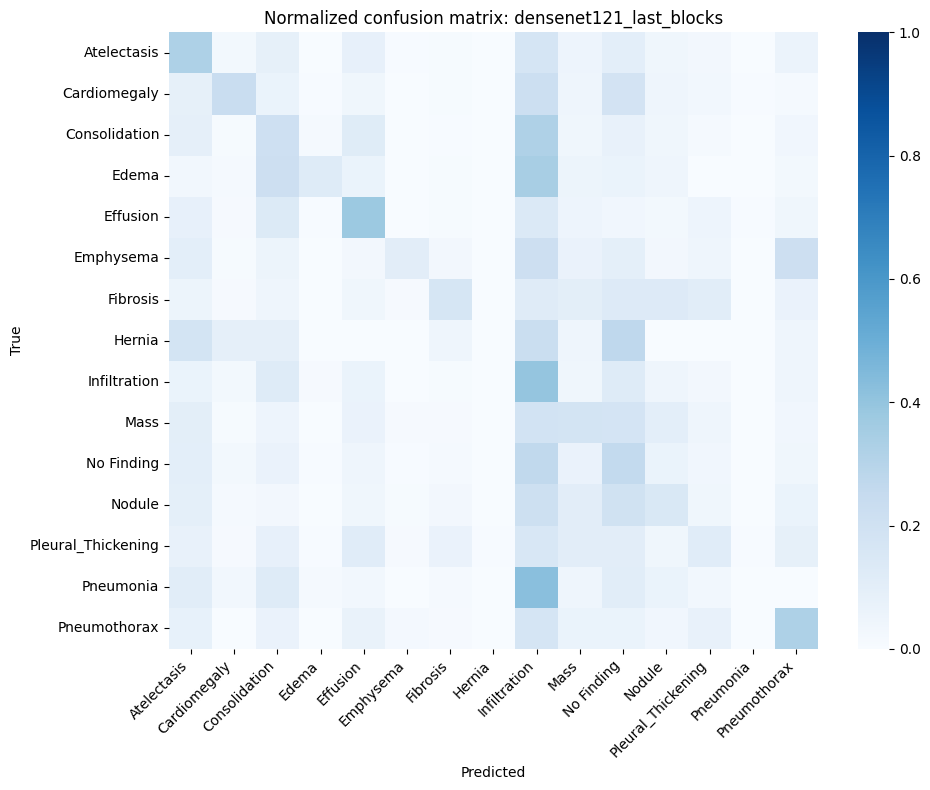

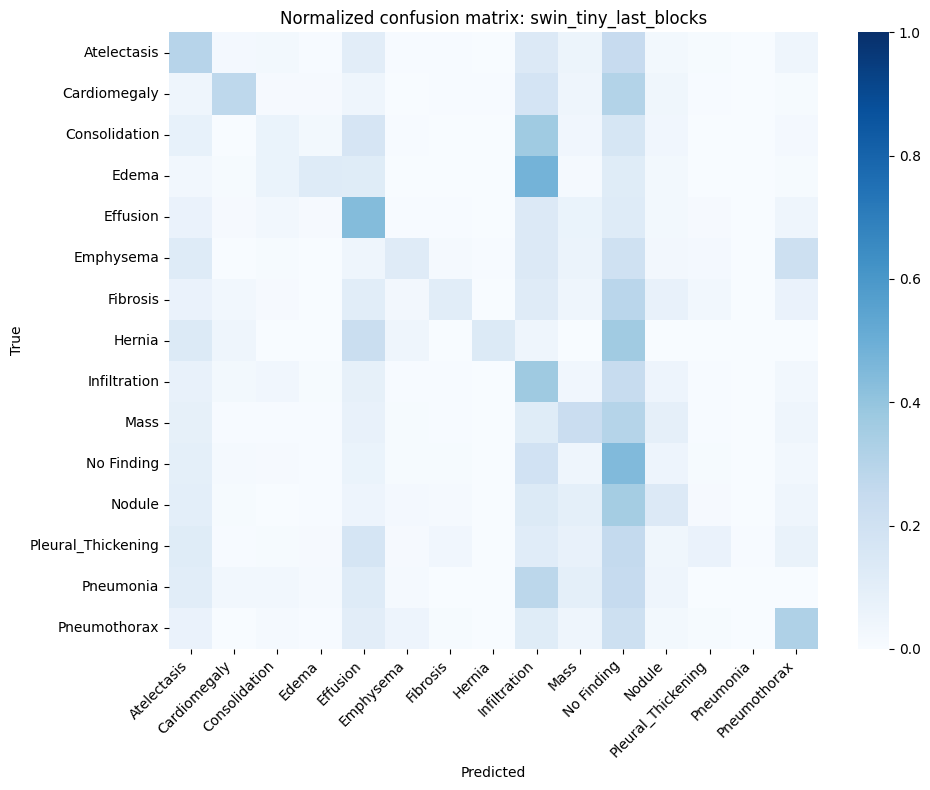

In [20]:
for model_name in MODELS_TO_RUN:
    if model_name == "swin_tiny" and timm is None:
        continue

    run_name = checkpoint_dir_name(model_name)
    pred_path = cfg.output_dir / run_name / "test_predictions.csv"
    if not pred_path.exists():
        continue

    pred_df = pd.read_csv(pred_path)
    cm = confusion_matrix(
        pred_df["target"],
        pred_df["prediction"],
        labels=list(range(num_classes)),
        normalize="true",
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues",
        vmin=0,
        vmax=1,
    )
    plt.title(f"Normalized confusion matrix: {run_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 14. Następny krok: augmentacja

Po zapisaniu baseline można dodać warianty transformacji tylko do `train_transform`, np. CLAHE, mocniejszy crop, brightness/contrast albo później syntetyczne obrazy. `val_loader` i `test_loader` muszą zostać bez augmentacji poza deterministycznym resize/normalize.